In [2]:
import pandas as pd
import numpy as np

In [3]:
df_metrics_portuguese = pd.read_csv(r'C:\Users\05646078199\Projetos\Projeto-Mestrado\Analise-Longitudinal\metrics_portuguese.csv')
df_main = pd.read_csv(r'C:\Users\05646078199\Projetos\Projeto-Mestrado\Corpus\metadados_completos_sol_sbc_com_idioma_area_introducao_conclusao.csv')

In [4]:
df_metrics_portuguese.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17160 entries, 0 to 17159
Columns: 201 entries, id_texto to ratio_function_to_content_words
dtypes: float64(192), int64(9)
memory usage: 26.3 MB


In [5]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29678 entries, 0 to 29677
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Title              29678 non-null  object
 1   Category           29678 non-null  object
 2   URL_Title          29678 non-null  object
 3   Authors            29678 non-null  object
 4   Event              29678 non-null  object
 5   Date               29678 non-null  object
 6   Box                29678 non-null  object
 7   Abstract           29677 non-null  object
 8   Keywords           29678 non-null  object
 9   Publisher          29678 non-null  object
 10  URL_Paper          29678 non-null  object
 11  index              29678 non-null  int64 
 12  Year               29678 non-null  int64 
 13  Paper_Language     23516 non-null  object
 14  has_intro          29678 non-null  int64 
 15  has_conclusion     29678 non-null  int64 
 16  flag_intro_conc    29678 non-null  int64

In [7]:
df_main = df_main[df_main['Abstract_Language'] == 'pt']

In [8]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17489 entries, 248 to 29677
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Title              17489 non-null  object
 1   Category           17489 non-null  object
 2   URL_Title          17489 non-null  object
 3   Authors            17489 non-null  object
 4   Event              17489 non-null  object
 5   Date               17489 non-null  object
 6   Box                17489 non-null  object
 7   Abstract           17489 non-null  object
 8   Keywords           17489 non-null  object
 9   Publisher          17489 non-null  object
 10  URL_Paper          17489 non-null  object
 11  index              17489 non-null  int64 
 12  Year               17489 non-null  int64 
 13  Paper_Language     16718 non-null  object
 14  has_intro          17489 non-null  int64 
 15  has_conclusion     17489 non-null  int64 
 16  flag_intro_conc    17489 non-null  int64 
 

In [10]:
df = pd.merge(df_metrics_portuguese, df_main, left_on='id_texto', right_on='index', how='inner')

In [12]:
df.head()

,id_texto,adjective_ratio,adverbs,content_words,flesch,function_words,sentences_per_paragraph,syllables_per_content_word,words_per_sentence,noun_ratio,...,index,Year,Paper_Language,has_intro,has_conclusion,flag_intro_conc,Introduction,Conclusion,Area,Abstract_Language
0,10002,0.08589,0.02454,0.60123,27.51603,0.39877,9.0,3.12245,18.11111,0.33129,...,10002,2024,en,1,1,1,Model selection is crucial in both industry an...,"In this study, we proposed a novel approach fo...",GERAL,pt
1,10011,0.05000,0.02000,0.60000,-11.72633,0.40000,3.0,3.61667,33.33333,0.36000,...,10011,2013,en,1,1,1,Developers often introduce errors to software ...,We introduce emergent interfaces (and feature-...,GERAL,pt
2,10016,0.06957,0.06087,0.62609,13.62217,0.37391,5.0,3.18056,23.00000,0.33043,...,10016,2022,en,1,1,1,The games industry has rapidly grown in recent...,"In this work, an SLR of the last five years wa...",SOC,pt
3,10021,0.09091,0.03030,0.57576,2.84809,0.42424,5.0,3.57895,26.40000,0.37879,...,10021,2020,en,1,1,1,"There are countless movements, actions and pro...","Cultural aspects, such as patriarchy, give wom...",SOC,pt
4,10023,0.11039,0.01948,0.59091,5.11669,0.40909,7.0,3.58242,22.00000,0.33766,...,10023,2019,en,1,1,1,Modeling and simulation techniques have been a...,Checkpoint strategies are essential to synchro...,GERAL,pt


# Frequência de Palavras e n-grams

In [14]:
pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------- ----- 1.6/1.8 MB 12.3 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 12.3 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 12.3 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.4 MB/s  0:00:00

   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   ---------------------------------------- 3/3 [nltk]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
from itertools import islice

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

ANO_CORTE = 2023                  # ano de referência do surgimento da IA generativa
TOP_N = 20                        # quantas palavras/n-grams mais frequentes considerar

# Garantir que Year seja numérico
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"])
df["Year"] = df["Year"].astype(int)

df = df.dropna(subset=["Abstract"]).reset_index(drop=True)

stop_words_pt = set(stopwords.words("portuguese"))

In [16]:
def preprocess_text(text: str) -> str:
    """Pré-processamento: minúsculas, remoção de pontuação, números e stopwords."""
    text = text.lower()
    text = re.sub(r"[^a-zà-ÿ\s]", " ", text)   # remove pontuação e números, mantém acentos
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in text.split() if t not in stop_words_pt and len(t) > 2]
    return " ".join(tokens)


df["Abstract_clean"] = df["Abstract"].astype(str).apply(preprocess_text)

Top unigramas (pós-2023): [('dados', np.int64(3620)), ('resultados', np.int64(3229)), ('trabalho', np.int64(2824)), ('artigo', np.int64(2395)), ('ensino', np.int64(2270)), ('desenvolvimento', np.int64(2059)), ('estudo', np.int64(1919)), ('apresenta', np.int64(1911)), ('sobre', np.int64(1799)), ('objetivo', np.int64(1772))]
Top bigramas (pós-2023): [('artigo apresenta', np.int64(874)), ('trabalho apresenta', np.int64(559)), ('pensamento computacional', np.int64(481)), ('aprendizado máquina', np.int64(415)), ('inteligência artificial', np.int64(384)), ('além disso', np.int64(376)), ('trabalho propõe', np.int64(338)), ('ensino fundamental', np.int64(296)), ('resultados indicam', np.int64(293)), ('neste trabalho', np.int64(290))]
Top trigramas (pós-2023): [('objetivo deste trabalho', np.int64(119)), ('processo ensino aprendizagem', np.int64(114)), ('revisão sistemática literatura', np.int64(104)), ('mapeamento sistemático literatura', np.int64(94)), ('ano ensino fundamental', np.int64(86))

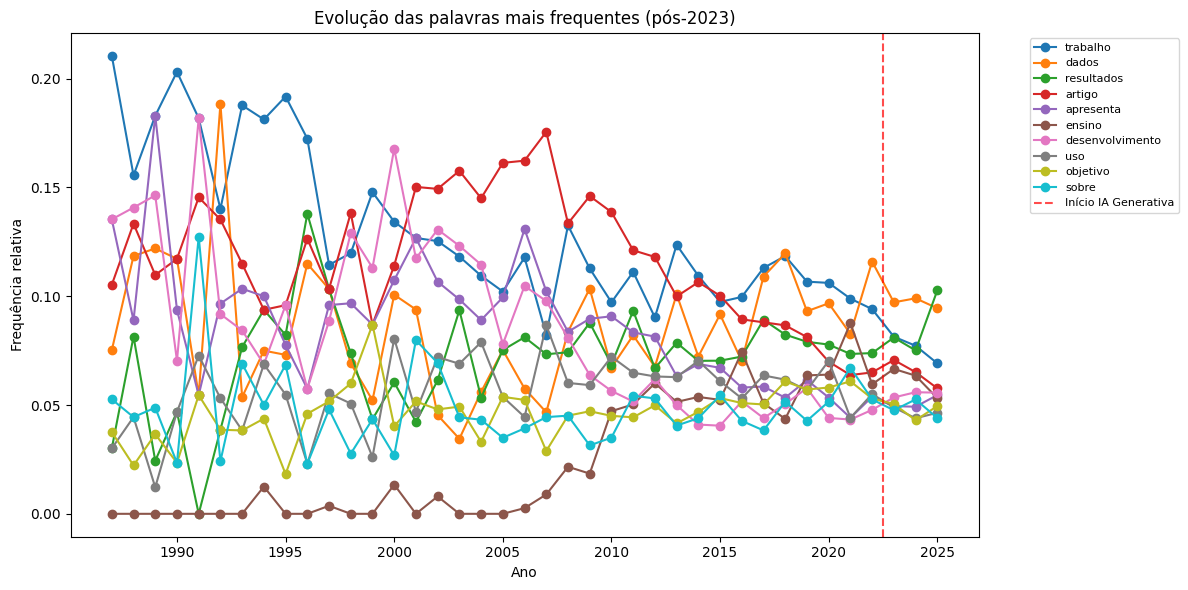

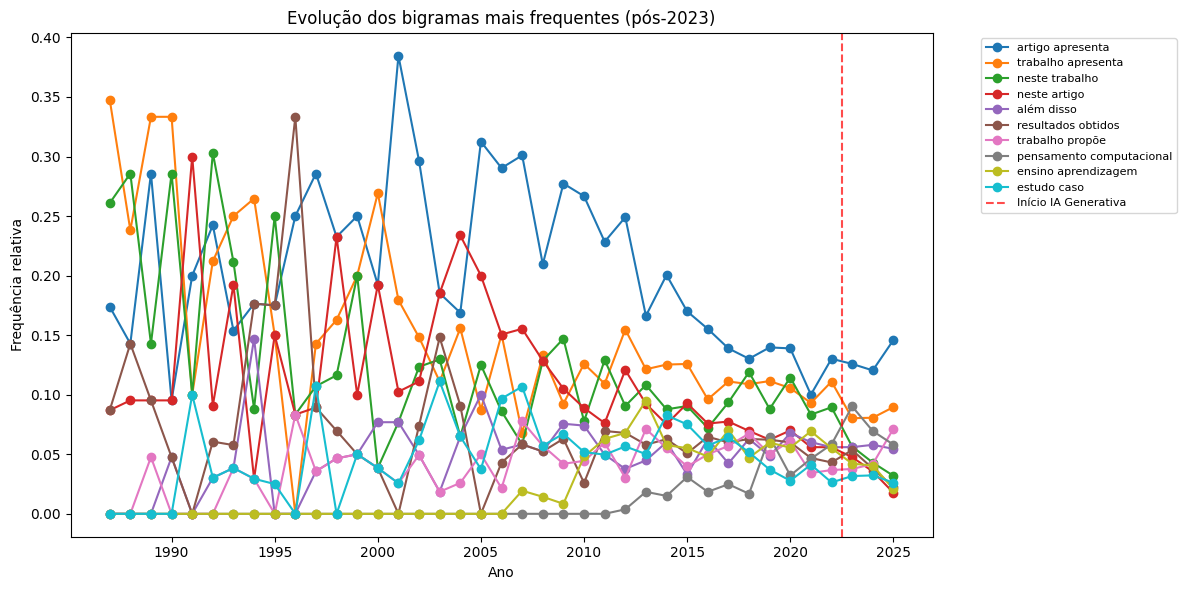

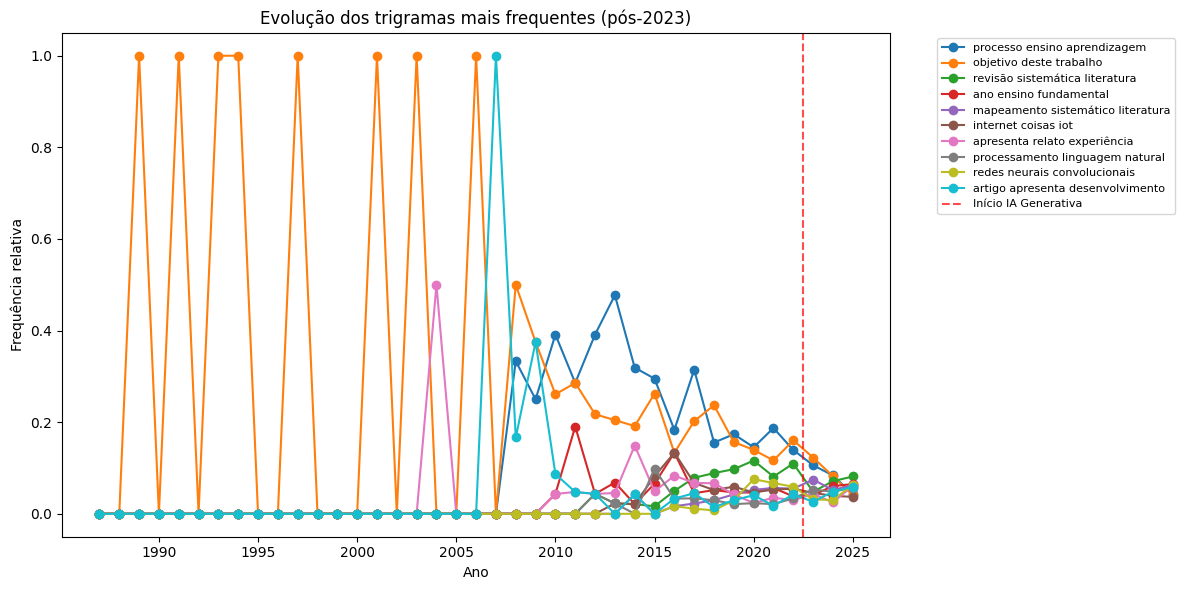

In [17]:
# Período pós-IA generativa
df_pos_ia = df[df["Year"] >= ANO_CORTE]
df_pre_ia = df[df["Year"] < ANO_CORTE]


def get_top_ngrams(corpus, ngram_range=(1, 1), top_n=20):
    """Retorna os N-grams mais frequentes de uma lista de textos."""
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    bag_of_words = vectorizer.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_n]


# --- Identificar top palavras / bigramas / trigramas no período pós-IA ---
top_unigramas = get_top_ngrams(df_pos_ia["Abstract_clean"], (1, 1), TOP_N)
top_bigramas = get_top_ngrams(df_pos_ia["Abstract_clean"], (2, 2), TOP_N)
top_trigramas = get_top_ngrams(df_pos_ia["Abstract_clean"], (3, 3), TOP_N)

print("Top unigramas (pós-2023):", top_unigramas[:10])
print("Top bigramas (pós-2023):", top_bigramas[:10])
print("Top trigramas (pós-2023):", top_trigramas[:10])


def ngram_freq_by_year(df, ngram_list, ngram_range):
    """
    Para cada n-gram da lista, calcula a frequência relativa por ano
    (frequência absoluta normalizada pelo total de tokens/n-grams do ano).
    """
    results = []
    for ano, group in df.groupby("Year"):
        vectorizer = CountVectorizer(ngram_range=ngram_range, vocabulary=[ng for ng, _ in ngram_list])
        bow = vectorizer.fit_transform(group["Abstract_clean"])
        total_ngrams = bow.sum()
        freqs = np.asarray(bow.sum(axis=0)).ravel()
        for ng, freq in zip(vectorizer.get_feature_names_out(), freqs):
            rel_freq = freq / total_ngrams if total_ngrams > 0 else 0
            results.append({"Year": ano, "ngram": ng, "freq_abs": freq, "freq_rel": rel_freq})
    return pd.DataFrame(results)


# Evolução temporal das palavras/n-grams mais frequentes do período pós-IA
evolucao_unigramas = ngram_freq_by_year(df, top_unigramas, (1, 1))
evolucao_bigramas = ngram_freq_by_year(df, top_bigramas, (2, 2))
evolucao_trigramas = ngram_freq_by_year(df, top_trigramas, (3, 3))


def plot_evolucao_ngrams(evolucao_df, titulo, top_k=10):
    """Plota a evolução temporal (freq relativa) dos top_k n-grams mais frequentes no total."""
    top_ngrams_geral = (
        evolucao_df.groupby("ngram")["freq_abs"].sum()
        .sort_values(ascending=False)
        .head(top_k)
        .index
    )
    plt.figure(figsize=(12, 6))
    for ng in top_ngrams_geral:
        sub = evolucao_df[evolucao_df["ngram"] == ng].sort_values("Year")
        plt.plot(sub["Year"], sub["freq_rel"], marker="o", label=ng)

    plt.axvline(x=ANO_CORTE - 0.5, color="red", linestyle="--", alpha=0.7, label="Início IA Generativa")
    plt.title(titulo)
    plt.xlabel("Ano")
    plt.ylabel("Frequência relativa")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


plot_evolucao_ngrams(evolucao_unigramas, "Evolução das palavras mais frequentes (pós-2023)")
plot_evolucao_ngrams(evolucao_bigramas, "Evolução dos bigramas mais frequentes (pós-2023)")
plot_evolucao_ngrams(evolucao_trigramas, "Evolução dos trigramas mais frequentes (pós-2023)")

# 2. Análise das Métricas Linguísticas

In [32]:
colunas_metadados = {
    "Title", "Category", "URL_Title", "Authors", "Event", "Date", "Box",
    "Abstract", "Keywords", "Publisher", "URL_Paper", "index", "Year",
    "Paper_Language", "has_intro", "has_conclusion", "flag_intro_conc",
    "Introduction", "Conclusion", "Area", "Abstract_Language",
    "Abstract_clean", "id_texto"  # coluna criada no Bloco 1
}

colunas_metricas = [
    c for c in df.columns
    if c not in colunas_metadados and pd.api.types.is_numeric_dtype(df[c])
]

print(f"\nQuantidade de métricas: {len(colunas_metricas)}")

# ---------------------------------------------------------------------
# 2. Média anual de cada métrica


medias_anuais = df.groupby("Year")[colunas_metricas].mean().sort_index()


Quantidade de métricas: 200


In [35]:
print("\nMédias anuais das métricas NILC-Metrix:")
medias_anuais.head(40)


Médias anuais das métricas NILC-Metrix:


,adjective_ratio,adverbs,content_words,flesch,function_words,sentences_per_paragraph,syllables_per_content_word,words_per_sentence,noun_ratio,paragraphs,...,relative_pronouns_ratio,relative_pronouns_diversity_ratio,subjunctive_future_ratio,subjunctive_imperfect_ratio,subjunctive_present_ratio,subordinate_clauses,temporal_adjunct_ratio,adverbs_before_main_verb_ratio,verbal_time_moods_diversity,ratio_function_to_content_words
Year,,,,,,,,,,,,,,,,,,,,,
1987,0.072634,0.021653,0.607149,4.041180,0.392851,2.758621,3.489521,24.134483,0.381346,1.000000,...,0.175226,0.402299,0.005337,0.000000,0.037843,0.423550,0.081233,0.106942,1.534483,0.654567
1988,0.070870,0.026212,0.612837,7.518783,0.387163,3.053571,3.401127,23.676211,0.382165,1.000000,...,0.213203,0.434524,0.000000,0.000000,0.013759,0.397796,0.013116,0.165823,1.410714,0.638284
1989,0.058303,0.013427,0.604356,14.183342,0.395644,3.500000,3.325836,23.245089,0.400050,1.000000,...,0.164815,0.433333,0.013889,0.000000,0.008796,0.358145,0.027163,0.141571,1.250000,0.663297
1990,0.067177,0.017364,0.594415,7.376008,0.405585,3.731707,3.472006,23.161585,0.367709,1.000000,...,0.226782,0.632114,0.007859,0.005759,0.018380,0.419482,0.029691,0.147276,1.707317,0.690055
1991,0.060109,0.018695,0.584674,8.450911,0.415326,3.800000,3.450557,24.969047,0.365802,1.000000,...,0.259285,0.394445,0.022222,0.000000,0.039987,0.455143,0.034874,0.132547,1.600000,0.718537
1992,0.065429,0.023020,0.589627,9.495936,0.410373,4.314815,3.426717,24.801654,0.369423,1.000000,...,0.202243,0.547619,0.006246,0.000000,0.041703,0.458381,0.042606,0.160006,1.722222,0.701909
1993,0.080744,0.020400,0.603058,5.804134,0.396942,3.973333,3.454208,24.600397,0.365165,1.000000,...,0.189451,0.496667,0.003089,0.000000,0.017756,0.428079,0.035553,0.133566,1.640000,0.663787
1994,0.063336,0.019244,0.589106,10.483595,0.410893,4.150000,3.432083,23.054167,0.358430,1.000000,...,0.230208,0.555000,0.000000,0.000000,0.027247,0.498415,0.065378,0.129091,1.775000,0.704170
1995,0.073785,0.025237,0.590676,9.979380,0.409324,4.440000,3.415050,24.611524,0.353601,1.000000,...,0.243129,0.624000,0.000000,0.000000,0.023025,0.468757,0.029487,0.160620,1.600000,0.698662


In [ ]:
# 3. Variação percentual entre anos consecutivos

# variação = ((valor_atual - valor_anterior) / valor_anterior)*100

variacoes = medias_anuais.pct_change() * 100
variacoes = variacoes.dropna(how="all")

In [26]:
variacoes.head(40)

,adjective_ratio,adverbs,content_words,flesch,function_words,sentences_per_paragraph,syllables_per_content_word,words_per_sentence,noun_ratio,paragraphs,...,relative_pronouns_ratio,relative_pronouns_diversity_ratio,subjunctive_future_ratio,subjunctive_imperfect_ratio,subjunctive_present_ratio,subordinate_clauses,temporal_adjunct_ratio,adverbs_before_main_verb_ratio,verbal_time_moods_diversity,ratio_function_to_content_words
Year,,,,,,,,,,,,,,,,,,,,,
1988,-2.428077,21.053390,0.936779,86.054173,-1.447788,10.691964,-2.533125,-1.898825,0.214757,0.000000,...,21.673491,8.010203,-100.000000,NaN,-63.640902,-6.080485,-83.853819,55.059250,-8.065811,-2.487726
1989,-17.733588,-48.774284,-1.383816,88.638791,2.190429,14.619883,-2.213701,-1.820908,4.680025,0.000000,...,-22.695818,-0.274000,inf,NaN,-36.070446,-9.967769,107.099614,-14.625352,-11.392405,3.918871
1990,15.221181,29.323620,-1.644993,-47.995278,2.512770,6.620209,4.394986,-0.359232,-8.084451,0.000000,...,37.597883,45.872439,-43.414459,inf,108.949906,17.126222,9.305346,4.029971,36.585366,4.034132
1991,-10.520735,7.664784,-1.638694,14.572975,2.401624,1.830065,-0.617756,7.803706,-0.518491,0.000000,...,14.332438,-37.599010,182.757743,-100.000000,117.561828,8.501195,17.456565,-10.000784,-6.285714,4.127394
1992,8.850108,23.134314,0.847145,12.365828,-1.192566,13.547758,-0.690922,-0.670404,0.989768,0.000000,...,-21.999773,38.832739,-71.891386,NaN,4.291359,0.711482,22.171033,20.716345,7.638889,-2.314143
1993,23.406301,-11.381675,2.277829,-38.877708,-3.272802,-7.914163,0.802257,-0.811466,-1.152373,0.000000,...,-6.325100,-9.304383,-50.545627,NaN,-57.423707,-6.610599,-16.553705,-16.524452,-4.774194,-5.431158
1994,-21.559727,-5.667900,-2.313416,80.622906,3.514676,4.446309,-0.640523,-6.285388,-1.844360,0.000000,...,21.513172,11.744966,-100.000000,NaN,53.454659,16.430616,83.887091,-3.350687,8.231707,6.083739
1995,16.498646,31.141135,0.266454,-4.809565,-0.382021,6.987952,-0.496292,6.755209,-1.347290,0.000000,...,5.612663,12.432468,NaN,NaN,-15.496018,-5.950550,-54.897327,24.424097,-9.859155,-0.782169
1996,7.344471,6.354959,1.242490,-56.216119,-1.792980,7.313196,0.844371,9.073047,-2.303255,0.000000,...,70.379554,5.423514,NaN,NaN,72.573512,9.497768,-64.706281,-2.034396,39.705882,-3.518299


In [27]:
# ---------------------------------------------------------------------
# 4-5. Comportamento histórico (pré-2023): média e desvio-padrão das variações
# ---------------------------------------------------------------------

# Consideramos como "históricas" as variações cujo ANO DE CHEGADA é < 2023
# (ex.: variação 2020->2021 é histórica; 2022->2023 já é a primeira avaliada)
variacoes_historicas = variacoes[variacoes.index < ANO_CORTE]

estatisticas_historicas = pd.DataFrame({
    "media_hist": variacoes_historicas.mean(),
    "desvio_hist": variacoes_historicas.std()
})

c:\Users\05646078199\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [38]:
estatisticas_historicas.head(50)

,media_hist,desvio_hist
adjective_ratio,0.466749,9.964595
adverbs,0.786206,15.525139
content_words,-0.069567,0.980080
flesch,8.865707,38.530748
function_words,0.121315,1.446585
sentences_per_paragraph,1.824407,8.093096
syllables_per_content_word,-0.104882,1.252738
words_per_sentence,0.386029,4.763506
noun_ratio,-0.065558,2.421476
paragraphs,0.001164,0.489121


In [40]:
# ---------------------------------------------------------------------
# 6. Variações específicas de interesse
# ---------------------------------------------------------------------

anos_interesse = [2023, 2024, 2025]  # variação X-1 -> X
variacoes_interesse = variacoes.loc[variacoes.index.isin(anos_interesse)]

print("\nVariações nos anos de interesse (%):")
print(variacoes_interesse.T.head(50))


Variações nos anos de interesse (%):
Year                             2023       2024       2025
 adjective_ratio             1.261070   4.776487  12.892435
adverbs                     -6.470841  -8.562293 -11.287585
content_words                0.312707   0.974495   2.543357
flesch                      -3.978796 -34.518814 -55.332543
function_words              -0.452926  -1.421061  -3.803635
sentences_per_paragraph     -2.121088  -2.262459   7.875096
syllables_per_content_word   0.442676   1.696423   1.486517
words_per_sentence          -1.481547  -0.614749  -4.683053
noun_ratio                   0.660044   1.679556   3.116638
paragraphs                   0.000000   0.000000   0.000000
sentences                   -2.121088  -2.262459   7.875096
words                       -3.248683  -2.538963   4.240095
pronoun_ratio               -6.582904  -9.247569 -19.891777
verbs                       -0.248713  -1.897150  -3.605762
logic_operators              2.486894   8.245874  10.951502
an

In [41]:
# ---------------------------------------------------------------------
# 7. Identificação de métricas com variações excepcionais (z-score)
# ---------------------------------------------------------------------

def calcular_zscores(variacoes_interesse, estatisticas_historicas):
    """
    Calcula o z-score de cada variação de interesse em relação
    à média/desvio histórico da métrica correspondente.
    z = (variacao_observada - media_historica) / desvio_historico
    """
    resultados = []
    for ano in variacoes_interesse.index:
        for metrica in variacoes_interesse.columns:
            var_obs = variacoes_interesse.loc[ano, metrica]
            media_h = estatisticas_historicas.loc[metrica, "media_hist"]
            desvio_h = estatisticas_historicas.loc[metrica, "desvio_hist"]

            if pd.isna(var_obs) or pd.isna(media_h) or pd.isna(desvio_h) or desvio_h == 0:
                z = np.nan
            else:
                z = (var_obs - media_h) / desvio_h

            resultados.append({
                "Metrica": metrica,
                "Transicao": f"{ano-1}->{ano}",
                "Variacao_%": var_obs,
                "Media_Historica_%": media_h,
                "Desvio_Historico_%": desvio_h,
                "Z_score": z
            })
    return pd.DataFrame(resultados)


tabela_zscores = calcular_zscores(variacoes_interesse, estatisticas_historicas)

# Threshold para "excepcional" (ex.: |z| > 2 -> fora do padrão histórico)
LIMIAR_Z = 1.0
tabela_zscores["Excepcional"] = tabela_zscores["Z_score"].abs() > LIMIAR_Z

metricas_excepcionais = (
    tabela_zscores[tabela_zscores["Excepcional"]]
    .sort_values("Z_score", key=lambda x: x.abs(), ascending=False)
)

print(f"\nMétricas com variação excepcional (|z| > {LIMIAR_Z}):")
print(metricas_excepcionais[["Metrica", "Transicao", "Variacao_%", "Z_score"]].head(30))


Métricas com variação excepcional (|z| > 1.0):
                             Metrica   Transicao  Variacao_%   Z_score
404                   function_words  2024->2025   -3.803635 -2.713252
539       idade_aquisicao_25_4_ratio  2024->2025  -17.418724 -2.701923
536             idade_aquisicao_mean  2024->2025    1.732386  2.696964
402                    content_words  2024->2025    2.543357  2.666032
599  ratio_function_to_content_words  2024->2025   -6.101120 -2.537871
498       sentences_with_zero_clause  2024->2025  342.247818  2.466248
488        prepositions_per_sentence  2024->2025  -13.274287 -2.456822
451                  content_density  2024->2025    6.855854  2.225861
412                    pronoun_ratio  2024->2025  -19.891777 -2.217385
336             idade_aquisicao_mean  2023->2024    1.399186  2.201708
477             clauses_per_sentence  2024->2025  -11.499431 -2.071351
457                     adj_stem_ovl  2024->2025  -24.863882 -1.855237
566                punctuatio


=== Top 20 métricas mais alteradas em 2022->2023 ===
                       Metrica  Variacao_%   Z_score
    idade_aquisicao_25_4_ratio   -7.381694 -1.199904
             dalechall_adapted   -1.754316 -1.140830
                 cross_entropy   -2.538151 -1.103034
             simple_word_ratio    2.871130  1.069175
          abstract_nouns_ratio    7.056463  1.031890
          idade_aquisicao_mean    0.606355  1.023274
           idade_aquisicao_std   -1.973817 -1.016658
    idade_aquisicao_55_7_ratio    4.336646  0.999763
                   cw_freq_bra    1.881438  0.850060
      familiaridade_55_7_ratio   -5.837873 -0.840136
adverbs_before_main_verb_ratio   -8.069952 -0.820765
             familiaridade_std   -1.801787 -0.817123
                  adj_stem_ovl   -9.655446 -0.800987
                 non_svo_ratio   -6.743536 -0.800569
                 pronoun_ratio   -6.582904 -0.782243
             adverbs_ambiguity   -9.795084 -0.773358
      familiaridade_4_55_ratio    1.863958  0

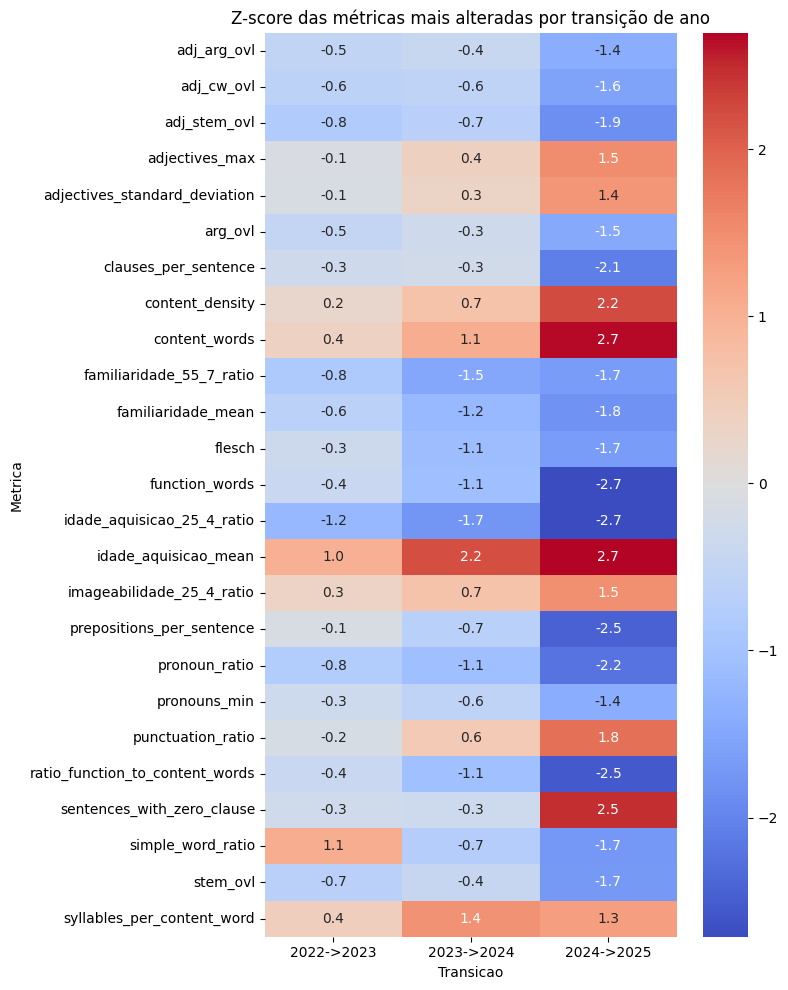

C:\Users\05646078199\AppData\Local\Temp\ipykernel_19140\2795726719.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sub, x="Variacao_%", y="Metrica", palette="vlag")


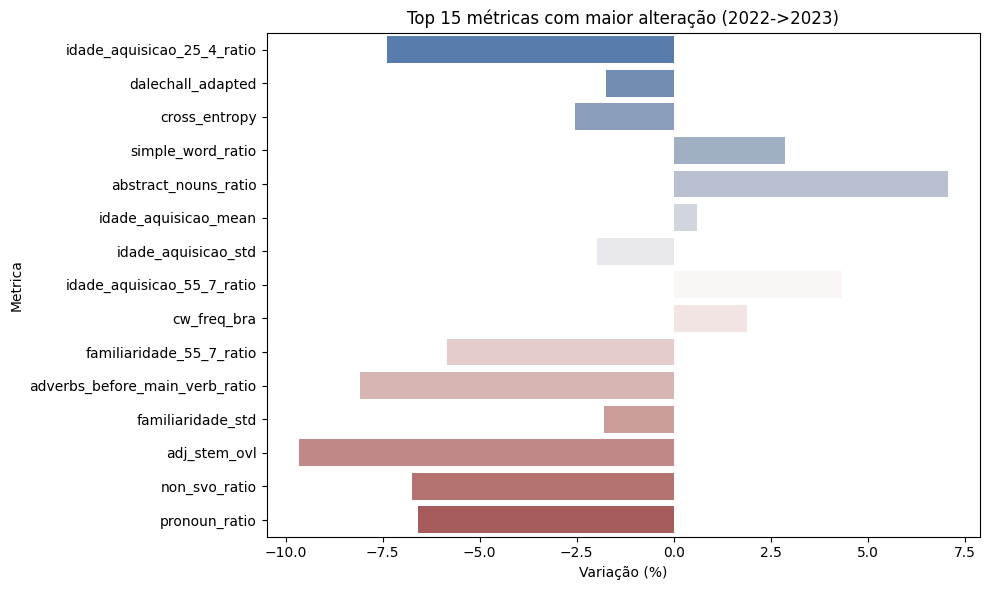

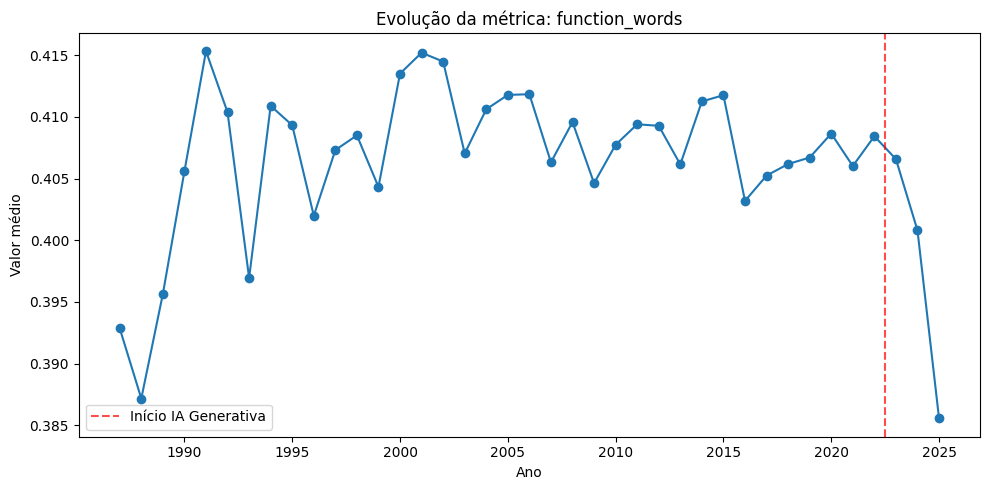

In [42]:
# ---------------------------------------------------------------------
# 8. Tabelas e visualizações finais
# ---------------------------------------------------------------------

# --- Tabela resumo: top 20 métricas mais alteradas em cada transição ---
for transicao in tabela_zscores["Transicao"].unique():
    sub = tabela_zscores[tabela_zscores["Transicao"] == transicao]
    top_alteradas = sub.reindex(sub["Z_score"].abs().sort_values(ascending=False).index).head(20)
    print(f"\n=== Top 20 métricas mais alteradas em {transicao} ===")
    print(top_alteradas[["Metrica", "Variacao_%", "Z_score"]].to_string(index=False))

# --- Heatmap: z-scores das métricas mais alteradas (visão geral) ---
top_metricas_geral = (
    tabela_zscores.groupby("Metrica")["Z_score"]
    .apply(lambda x: x.abs().max())
    .sort_values(ascending=False)
    .head(25)
    .index
)

pivot_zscore = tabela_zscores[tabela_zscores["Metrica"].isin(top_metricas_geral)].pivot(
    index="Metrica", columns="Transicao", values="Z_score"
)

plt.figure(figsize=(8, 10))
sns.heatmap(pivot_zscore, annot=True, fmt=".1f", cmap="coolwarm", center=0)
plt.title("Z-score das métricas mais alteradas por transição de ano")
plt.tight_layout()
plt.show()

# --- Gráfico de barras: variação % das top métricas na transição 2022->2023 ---
transicao_alvo = "2022->2023"
if transicao_alvo in tabela_zscores["Transicao"].values:
    sub = tabela_zscores[tabela_zscores["Transicao"] == transicao_alvo]
    top_sub = sub.reindex(sub["Z_score"].abs().sort_values(ascending=False).index).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_sub, x="Variacao_%", y="Metrica", palette="vlag")
    plt.title(f"Top 15 métricas com maior alteração ({transicao_alvo})")
    plt.xlabel("Variação (%)")
    plt.tight_layout()
    plt.show()

# --- Série temporal de uma métrica específica (exemplo) ---
def plot_serie_metrica(metrica):
    plt.figure(figsize=(10, 5))
    plt.plot(medias_anuais.index, medias_anuais[metrica], marker="o")
    plt.axvline(x=ANO_CORTE - 0.5, color="red", linestyle="--", alpha=0.7, label="Início IA Generativa")
    plt.title(f"Evolução da métrica: {metrica}")
    plt.xlabel("Ano")
    plt.ylabel("Valor médio")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Exemplo de uso (substitua pelo nome real de uma métrica do seu dataset):
if len(metricas_excepcionais) > 0:
    plot_serie_metrica(metricas_excepcionais.iloc[0]["Metrica"])